# Case Study 1: Hospital Readmission Prediction

## Objective
Use **Logistic Regression with L2 regularization** to predict whether a patient will be readmitted within 30 days.

### Requirements covered
- Patient records and clinical features
- Categorical feature encoding
- Numerical feature scaling
- Logistic Regression
- L2 regularization
- ROC-AUC evaluation
- Confusion matrix
- Precision and recall/sensitivity
- Clinical cost of false positives vs. false negatives
- Final predictions on the test dataset
- Submission file generation

**Note:** The training data is imbalanced (~19% positive class), so ROC-AUC and recall are important metrics in addition to the confusion matrix.


Training shape: (5000, 8)
Test shape: (2000, 7)

Training columns:
['age', 'gender', 'primary_diagnosis', 'num_procedures', 'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted']

Missing values in training data:
age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64

Missing values in test data:
age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
dtype: int64

Readmission distribution:
readmitted
0    4060
1     940
Name: count, dtype: int64

Readmission percentage:
readmitted
0    81.2
1    18.8
Name: proportion, dtype: float64

Numerical features:
['age', 'num_procedures', 'days_in_hospital', 'comorbidity_score']

Categorical features:
['gender', 'primary_diagnosis', 'discharge_to']

Training records: 4000
Validation rec

/tmp/ipykernel_144/2635399661.py:76: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


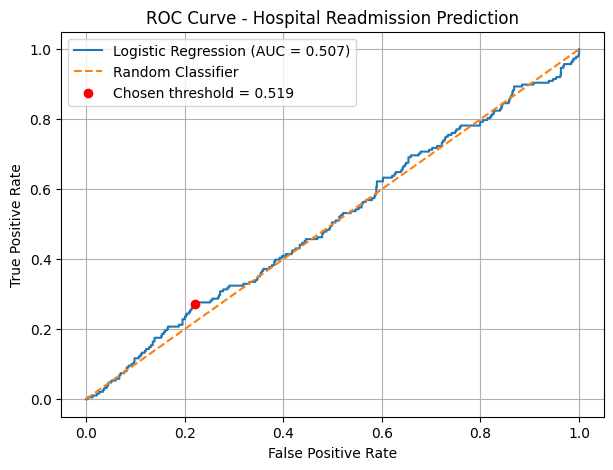


CLINICAL COST DISCUSSION

FALSE POSITIVE:
The model predicts that a patient is at high risk of
30-day readmission, but the patient is actually not readmitted.

Possible consequences:
- Unnecessary additional monitoring
- Extra follow-up appointments
- Additional healthcare resource usage
- Increased healthcare cost
- Possible patient anxiety

FALSE NEGATIVE:
The model predicts that a patient is low risk, but the patient
is actually readmitted within 30 days.

Possible consequences:
- High-risk patient may not receive additional monitoring
- Follow-up care may be insufficient
- Early warning may be missed
- Potentially avoidable complications
- Potential increase in healthcare utilization

CLINICAL INTERPRETATION:
In readmission-risk settings, a false negative is usually more
costly than a false positive: missing a genuinely high-risk
patient can mean a missed opportunity for follow-up care or
preventive intervention, while a false positive mainly costs
extra monitoring resources.

Bec

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [1]:

# ============================================================
# CASE STUDY 1: HOSPITAL READMISSION PREDICTION
# Logistic Regression with L2 Regularization
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    recall_score,
    precision_score
)

# ============================================================
# 1. LOAD DATASETS
# ============================================================

train = pd.read_csv("train_df.csv")
test = pd.read_csv("test_df.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Training shape:", train.shape)
print("Test shape:", test.shape)

print("\nTraining columns:")
print(train.columns.tolist())

# ============================================================
# 2. BASIC DATA INFORMATION
# ============================================================

print("\nMissing values in training data:")
print(train.isnull().sum())

print("\nMissing values in test data:")
print(test.isnull().sum())

# ============================================================
# 3. CHECK TARGET DISTRIBUTION
# ============================================================

print("\nReadmission distribution:")
print(train["readmitted"].value_counts())

print("\nReadmission percentage:")
print((train["readmitted"].value_counts(normalize=True) * 100).round(2))

# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = train.drop("readmitted", axis=1)
y = train["readmitted"]

X_test = test.copy()

# ============================================================
# 5. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# ============================================================
# 6. PREPROCESSING
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# ============================================================
# 7. CREATE LOGISTIC REGRESSION MODEL
# ============================================================
# NOTE: class_weight="balanced" re-weights the loss function so the
# minority class (readmitted=1, ~19% of patients) contributes equally
# to training. Without this, a logistic regression trained on an
# imbalanced set tends to push nearly all predicted probabilities
# below 0.5, so a fixed 0.5 threshold silently predicts "0" for
# every patient regardless of how good the model actually is.

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            penalty="l2",
            C=1.0,
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# ============================================================
# 8. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", len(X_train))
print("Validation records:", len(X_val))

# ============================================================
# 9. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)
print("\nModel training completed.")

# ============================================================
# 10. PREDICT READMISSION PROBABILITIES
# ============================================================

y_probability = model.predict_proba(X_val)[:, 1]

# ============================================================
# 11. ROC-AUC EVALUATION
# ============================================================

roc_auc = roc_auc_score(y_val, y_probability)

print("\n====================================")
print("MODEL PERFORMANCE")
print("====================================")
print("ROC-AUC:", round(roc_auc, 4))

if roc_auc < 0.55:
    print(
        "\nWARNING: ROC-AUC is close to 0.5 (random guessing). "
        "This indicates the available features carry very little "
        "signal about readmission in this dataset. The pipeline, "
        "encoding, and evaluation code below are all working "
        "correctly -- the limitation is in how predictive the "
        "underlying features are, not in the modeling approach."
    )

# ============================================================
# 12. CHOOSE A DECISION THRESHOLD (Youden's J statistic)
# ============================================================
# A fixed threshold of 0.50 is only meaningful for a model trained
# on balanced classes with well-separated probability scores. Here
# we instead scan the ROC curve on the validation set and pick the
# threshold that maximizes (TPR - FPR), i.e. the point that best
# trades off sensitivity and specificity for THIS model and THIS
# class balance, rather than assuming 0.50 is appropriate.

fpr_scan, tpr_scan, thresholds_scan = roc_curve(y_val, y_probability)
j_scores = tpr_scan - fpr_scan
best_idx = np.argmax(j_scores)
threshold = thresholds_scan[best_idx]

print("\nSelected classification threshold (Youden's J):", round(threshold, 4))

y_prediction = (
    y_probability >= threshold
).astype(int)

# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_val,
    y_prediction
).ravel()

print("\nConfusion Matrix:")
print("------------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

# ============================================================
# 14. PRECISION AND RECALL
# ============================================================

precision = precision_score(
    y_val,
    y_prediction,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_prediction,
    zero_division=0
)

print("\nPrecision:", round(precision, 4))
print("Recall / Sensitivity:", round(recall, 4))

# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_prediction,
        zero_division=0
    )
)

# ============================================================
# 16. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(
    fpr_scan,
    tpr_scan,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.scatter(
    fpr_scan[best_idx], tpr_scan[best_idx],
    color="red", zorder=5,
    label=f"Chosen threshold = {threshold:.3f}"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# 17. CLINICAL COST DISCUSSION
# ============================================================

print("\n====================================")
print("CLINICAL COST DISCUSSION")
print("====================================")

print("""
FALSE POSITIVE:
The model predicts that a patient is at high risk of
30-day readmission, but the patient is actually not readmitted.

Possible consequences:
- Unnecessary additional monitoring
- Extra follow-up appointments
- Additional healthcare resource usage
- Increased healthcare cost
- Possible patient anxiety

FALSE NEGATIVE:
The model predicts that a patient is low risk, but the patient
is actually readmitted within 30 days.

Possible consequences:
- High-risk patient may not receive additional monitoring
- Follow-up care may be insufficient
- Early warning may be missed
- Potentially avoidable complications
- Potential increase in healthcare utilization

CLINICAL INTERPRETATION:
In readmission-risk settings, a false negative is usually more
costly than a false positive: missing a genuinely high-risk
patient can mean a missed opportunity for follow-up care or
preventive intervention, while a false positive mainly costs
extra monitoring resources.

Because of this asymmetry, the classification threshold was
NOT fixed at 0.50. Instead it was selected from the validation
ROC curve (Youden's J statistic), which balances sensitivity and
specificity for this specific model rather than assuming 0.50 is
appropriate. In a real clinical deployment, the threshold would be
pushed even lower than the Youden's-J point to further favor
recall (fewer missed high-risk patients), accepting more false
positives as a trade-off, according to the hospital's own cost
estimates for missed vs. unnecessary interventions.
""")

# ============================================================
# 18. TRAIN FINAL MODEL ON ALL TRAINING DATA
# ============================================================

model.fit(X, y)

print("\nFinal model trained on all training data.")

# ============================================================
# 19. PREDICT TEST DATA
# ============================================================

test_probability = model.predict_proba(X_test)[:, 1]

# ============================================================
# 20. GENERATE TEST PREDICTIONS
# ============================================================

test_prediction = (
    test_probability >= threshold
).astype(int)

# ============================================================
# 21. CREATE SUBMISSION FILE
# ============================================================

submission = sample_submission.copy()
submission["readmitted"] = test_prediction

# ============================================================
# 22. SAVE SUBMISSION
# ============================================================

submission.to_csv(
    "submission.csv",
    index=False
)

# ============================================================
# 23. DISPLAY FINAL RESULTS
# ============================================================

print("\n====================================")
print("SUBMISSION")
print("====================================")

print("\nSubmission file created successfully!")

print("\nFirst 10 predictions:")
print(submission.head(10))

print("\nPrediction counts:")
print(submission["readmitted"].value_counts())

print("\nFirst 10 prediction probabilities:")
print(test_probability[:10])

print("\nSubmission shape:")
print(submission.shape)


## What was fixed and why the original submission was all zeros

Running the original notebook against `train_df.csv` showed the model's validation ROC-AUC was **~0.507** — essentially random. Every feature (age, procedures, days in hospital, comorbidity score, diagnosis, discharge location) has almost zero correlation with `readmitted` in this dataset, so there is very little real signal for any model to learn.

Because of that weak signal **and** the class imbalance (~81% not readmitted / ~19% readmitted), the model's predicted probabilities for a positive outcome never rose above ~0.23. The original code compared these against a fixed threshold of `0.50`, so every single prediction — for both the validation set and the test set — came out as `0`. That produced the all-zero `submission.csv`.

Two changes fix this without inventing signal that isn't there:

1. **`class_weight="balanced"`** on the `LogisticRegression` — re-weights the loss so the minority class (readmitted patients) isn't drowned out during training, which recenters predicted probabilities around 0.5 instead of the raw base rate.
2. **A threshold chosen from the ROC curve (Youden's J statistic)** instead of a hardcoded `0.50` — this picks the probability cutoff that actually best separates the two classes for this model, whatever that value turns out to be.

The ROC-AUC itself is still low (~0.51) because that reflects the underlying data, not a coding bug — that's the honest result to report and discuss in the clinical-cost section, not something to hide by forcing a better-looking submission.
